<a href="https://colab.research.google.com/github/mptorpo/integracion_prospectiva_y_datos/blob/main/Parcial_1_Miguel_Pimiento_Restrepo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial 1: Entidad Prestadora de Salud**
Una entidad prestadora de salud quiere mejorar la eficiencia en la prestación de sus servicios de salud, para lo cual quiere cerrar su sucursal de Sabaneta. Para reubicar a sus pacientes, se quiere determinar cuál de las demás sucursales (Bello, Medellín, Envigado, Caldas) tiene mayor afinidad con Sabaneta utilizando la variable de referencia Glucose (variable representativa de pacientes con Diabetes). Nota: La sucursal de Itagüí no cuenta con la variable Glucose en su base de datos, por lo tanto, no se incluye en el análisis de integración. Se utilizarán las siguientes técnicas:
- **Teoría de la Credibilidad:** Para determinar la afinidad entre Sabaneta y cada sucursal.
- **Método de Valor de Pertenencia (Aceptación/Rechazo I):** Para clasificar pacientes de Sabaneta en la sucursal con mayor credibilidad.
- **Método de Aceptación/Rechazo II:** Para integrar pacientes comparando valores de pertenencia internos vs externos.
- **Método de Aceptación/Rechazo III:** Para integrar pacientes mediante componente aleatorio.

**0. Se procede con la carga de las librerías de trabajo**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Caracterización de Distribuciones de Probabilidad
def caracterizacion(LDA, nombre=""):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Glucose (mg/dL)")
  plt.title(f"Distribución de Glucose - {nombre}")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  print(df)

  #Se procede con la estimación de la media, sigma, asimetría y kurtosis
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  print(f"\nMedia: {u:.4f}")
  print(f"Desviación Estándar: {sigma:.4f}")
  print(f"Coeficiente de Asimetría: {Cas:.4f}")
  print(f"Kurtosis: {Kur:.4f}")

  return u,sigma,Cas,Kur,df

**1. Se procede con la carga de los archivos de trabajo y la caracterización de cada sucursal**

In [ ]:
#Se procede con la carga de la base de datos
nxl='3. Parcial - medical_attention_data.xlsx'

#Se cargan los datos de cada sucursal
XDB_sab=pd.read_excel(nxl,sheet_name='Sabaneta') #Sucursal a cerrar (datos internos)
XDB_bel=pd.read_excel(nxl,sheet_name='Bello') #Sucursal externa
XDB_med=pd.read_excel(nxl,sheet_name='Medellín') #Sucursal externa
XDB_env=pd.read_excel(nxl,sheet_name='Envigado') #Sucursal externa
XDB_cal=pd.read_excel(nxl,sheet_name='Caldas') #Sucursal externa

#Se extrae la variable de referencia: Glucose
LDA_sab=np.array(XDB_sab['Glucose']) #Datos internos (Sabaneta - sucursal a cerrar)
LDA_bel=np.array(XDB_bel['Glucose']) #Datos externos (Bello)
LDA_med=np.array(XDB_med['Glucose']) #Datos externos (Medellín)
LDA_env=np.array(XDB_env['Glucose']) #Datos externos (Envigado)
LDA_cal=np.array(XDB_cal['Glucose']) #Datos externos (Caldas)

print("Datos cargados correctamente")
print(f"Sabaneta (a cerrar): {len(LDA_sab)} pacientes")
print(f"Bello: {len(LDA_bel)} pacientes")
print(f"Medellín: {len(LDA_med)} pacientes")
print(f"Envigado: {len(LDA_env)} pacientes")
print(f"Caldas: {len(LDA_cal)} pacientes")

Datos cargados correctamente
Sabaneta (a cerrar): 621 pacientes
Bello: 502 pacientes
Medellín: 895 pacientes
Envigado: 792 pacientes
Caldas: 909 pacientes


1.1 Caracterización de la distribución de Sabaneta (datos internos - sucursal a cerrar)

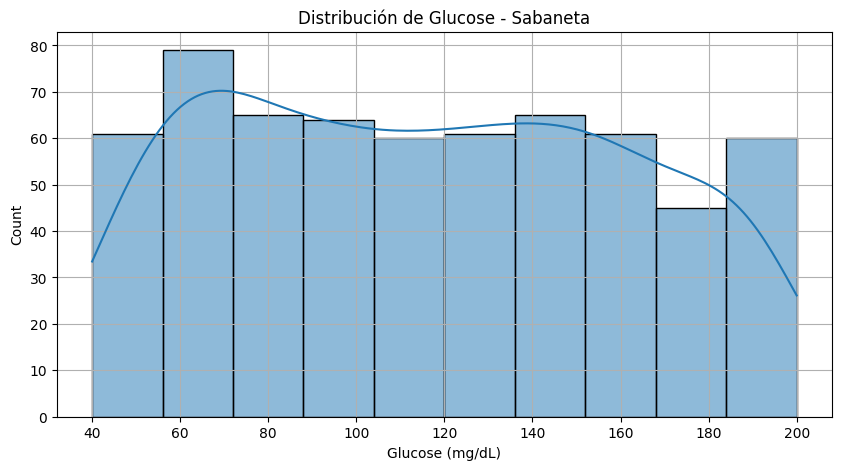

El número de datos por intervalo es:
[61 79 65 64 60 61 65 61 45 60]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC    ND
0   40.0   56.0   48.0  61.0
1   56.0   72.0   64.0  79.0
2   72.0   88.0   80.0  65.0
3   88.0  104.0   96.0  64.0
4  104.0  120.0  112.0  60.0
5  120.0  136.0  128.0  61.0
6  136.0  152.0  144.0  65.0
7  152.0  168.0  160.0  61.0
8  168.0  184.0  176.0  45.0
9  184.0  200.0  192.0  60.0

Media: 116.6119
Desviación Estándar: 45.6241
Coeficiente de Asimetría: 0.1115
Kurtosis: -1.2023


In [ ]:
#Se procede con la caracterización de la distribución de Sabaneta
u_sab,sigma_sab,Cas_sab,Kur_sab,df_sab=caracterizacion(LDA_sab,"Sabaneta")

1.2 Caracterización de la distribución de Bello

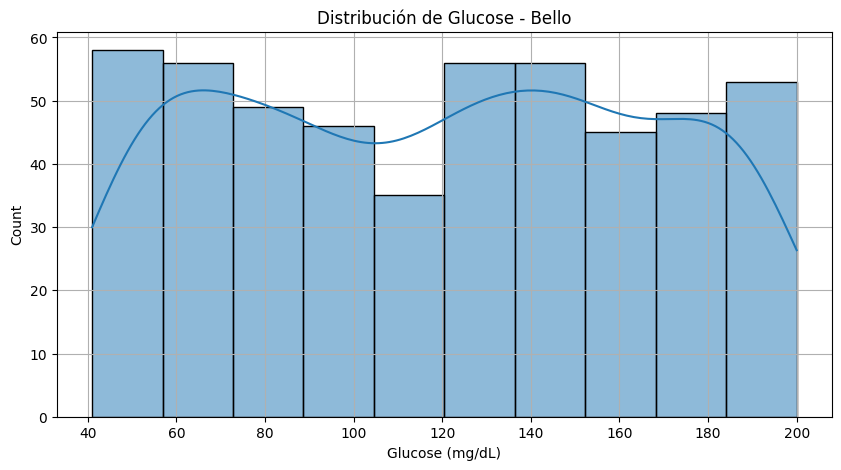

El número de datos por intervalo es:
[58 56 49 46 35 56 56 45 48 53]
Los intervalos inferiores:
[ 41.   56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1]
Los intervalos superiores:
[ 56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1 200. ]
      LI     LS      XC    ND
0   41.0   56.9   48.95  58.0
1   56.9   72.8   64.85  56.0
2   72.8   88.7   80.75  49.0
3   88.7  104.6   96.65  46.0
4  104.6  120.5  112.55  35.0
5  120.5  136.4  128.45  56.0
6  136.4  152.3  144.35  56.0
7  152.3  168.2  160.25  45.0
8  168.2  184.1  176.15  48.0
9  184.1  200.0  192.05  53.0

Media: 119.3914
Desviación Estándar: 46.8535
Coeficiente de Asimetría: 0.0068
Kurtosis: -1.2771


In [ ]:
#Se procede con la caracterización de la distribución de Bello
u_bel,sigma_bel,Cas_bel,Kur_bel,df_bel=caracterizacion(LDA_bel,"Bello")

1.3 Caracterización de la distribución de Medellín

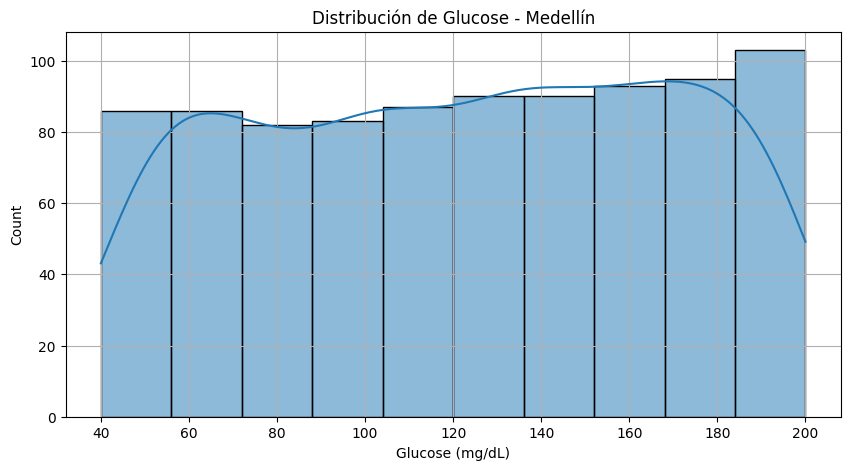

El número de datos por intervalo es:
[ 86  86  82  83  87  90  90  93  95 103]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   86.0
1   56.0   72.0   64.0   86.0
2   72.0   88.0   80.0   82.0
3   88.0  104.0   96.0   83.0
4  104.0  120.0  112.0   87.0
5  120.0  136.0  128.0   90.0
6  136.0  152.0  144.0   90.0
7  152.0  168.0  160.0   93.0
8  168.0  184.0  176.0   95.0
9  184.0  200.0  192.0  103.0

Media: 122.6369
Desviación Estándar: 46.4631
Coeficiente de Asimetría: -0.0732
Kurtosis: -1.2369


In [ ]:
#Se procede con la caracterización de la distribución de Medellín
u_med,sigma_med,Cas_med,Kur_med,df_med=caracterizacion(LDA_med,"Medellín")

1.4 Caracterización de la distribución de Envigado

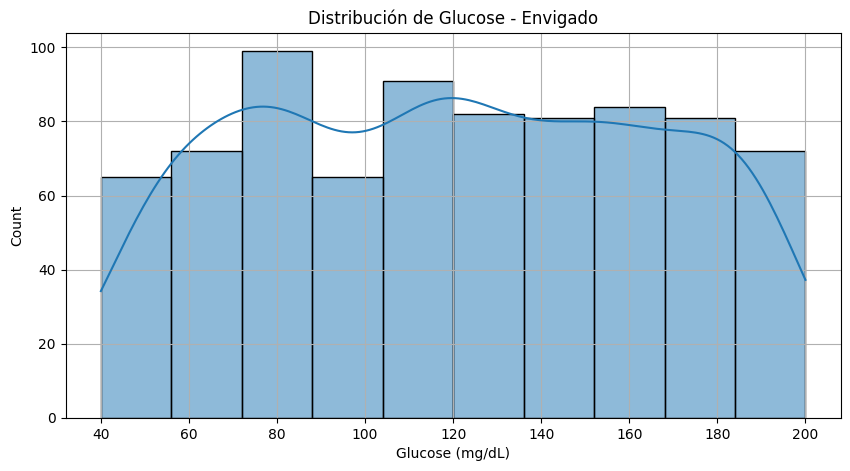

El número de datos por intervalo es:
[65 72 99 65 91 82 81 84 81 72]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC    ND
0   40.0   56.0   48.0  65.0
1   56.0   72.0   64.0  72.0
2   72.0   88.0   80.0  99.0
3   88.0  104.0   96.0  65.0
4  104.0  120.0  112.0  91.0
5  120.0  136.0  128.0  82.0
6  136.0  152.0  144.0  81.0
7  152.0  168.0  160.0  84.0
8  168.0  184.0  176.0  81.0
9  184.0  200.0  192.0  72.0

Media: 120.9091
Desviación Estándar: 44.6271
Coeficiente de Asimetría: -0.0121
Kurtosis: -1.1857


In [ ]:
#Se procede con la caracterización de la distribución de Envigado
u_env,sigma_env,Cas_env,Kur_env,df_env=caracterizacion(LDA_env,"Envigado")

1.5 Caracterización de la distribución de Caldas

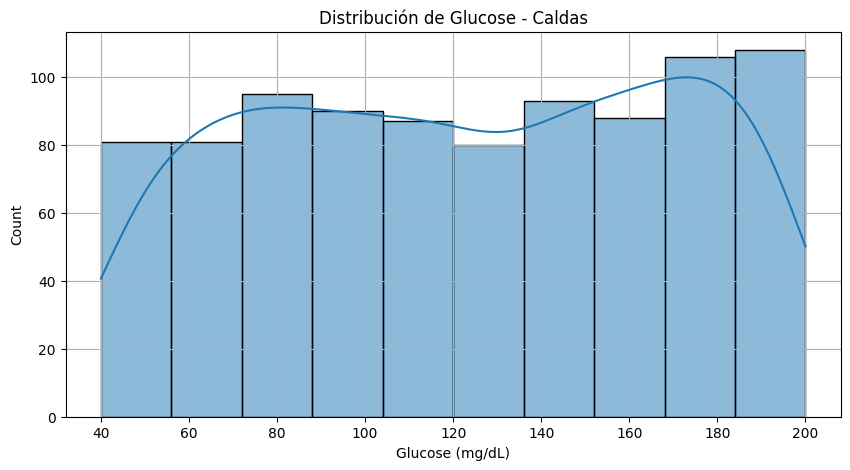

El número de datos por intervalo es:
[ 81  81  95  90  87  80  93  88 106 108]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   81.0
1   56.0   72.0   64.0   81.0
2   72.0   88.0   80.0   95.0
3   88.0  104.0   96.0   90.0
4  104.0  120.0  112.0   87.0
5  120.0  136.0  128.0   80.0
6  136.0  152.0  144.0   93.0
7  152.0  168.0  160.0   88.0
8  168.0  184.0  176.0  106.0
9  184.0  200.0  192.0  108.0

Media: 123.3883
Desviación Estándar: 46.4903
Coeficiente de Asimetría: -0.0651
Kurtosis: -1.2589


In [ ]:
#Se procede con la caracterización de la distribución de Caldas
u_cal,sigma_cal,Cas_cal,Kur_cal,df_cal=caracterizacion(LDA_cal,"Caldas")

**2. Se procede con la estimación de la Teoría de la Credibilidad entre Sabaneta y cada sucursal**

In [ ]:
#Se definen los tamaños de muestra
ND_sab=len(LDA_sab)
ND_bel=len(LDA_bel)
ND_med=len(LDA_med)
ND_env=len(LDA_env)
ND_cal=len(LDA_cal)

#Se almacenan las sucursales externas para iterar
sucursales={'Bello':(u_bel,sigma_bel,ND_bel),
            'Medellín':(u_med,sigma_med,ND_med),
            'Envigado':(u_env,sigma_env,ND_env),
            'Caldas':(u_cal,sigma_cal,ND_cal)}

print("="*60)
print("TEORÍA DE LA CREDIBILIDAD - Sabaneta vs cada sucursal")
print("="*60)

credibilidades={}

for nombre,(ue,sigmae,NDe) in sucursales.items():

  #Se procede con el Valor Esperado de la Varianza (EPV)
  EPV=(sigma_sab*ND_sab+sigmae*NDe)/(ND_sab+NDe)

  #Se procede con la estimación del Valor Hipotético de la Media (VHM)
  uh=(u_sab*ND_sab+ue*NDe)/(ND_sab+NDe)
  VHM=((ND_sab*u_sab**2+NDe*ue**2)/(ND_sab+NDe))-uh**2

  #Se procede con la estimación del factor de credibilidad (fc)
  fc=EPV/VHM

  #Se procede con la estimación de la credibilidad
  Cr=ND_sab/(ND_sab+fc)

  credibilidades[nombre]=Cr

  print(f"\n--- Sabaneta vs {nombre} ---")
  print(f"Media Sabaneta: {u_sab:.4f}")
  print(f"Media {nombre}: {ue:.4f}")
  print(f"EPV: {EPV:.4f}")
  print(f"VHM: {VHM:.4f}")
  print(f"Factor de Credibilidad (fc): {fc:.4f}")
  print(f"Credibilidad (Cr): {Cr:.4f} ({Cr*100:.2f}%)")

TEORÍA DE LA CREDIBILIDAD - Sabaneta vs cada sucursal

--- Sabaneta vs Bello ---
Media Sabaneta: 116.6119
Media Bello: 119.3914
EPV: 46.1736
VHM: 1.9097
Factor de Credibilidad (fc): 24.1779
Credibilidad (Cr): 0.9625 (96.25%)

--- Sabaneta vs Medellín ---
Media Sabaneta: 116.6119
Media Medellín: 122.6369
EPV: 46.1194
VHM: 8.7786
Factor de Credibilidad (fc): 5.2536
Credibilidad (Cr): 0.9916 (99.16%)

--- Sabaneta vs Envigado ---
Media Sabaneta: 116.6119
Media Envigado: 120.9091
EPV: 45.0653
VHM: 4.5488
Factor de Credibilidad (fc): 9.9070
Credibilidad (Cr): 0.9843 (98.43%)

--- Sabaneta vs Caldas ---
Media Sabaneta: 116.6119
Media Caldas: 123.3883
EPV: 46.1387
VHM: 11.0732
Factor de Credibilidad (fc): 4.1667
Credibilidad (Cr): 0.9933 (99.33%)


In [ ]:
#Se identifica la sucursal con mayor credibilidad (mayor afinidad con Sabaneta)
mejor_sucursal=max(credibilidades,key=credibilidades.get)
mejor_Cr=credibilidades[mejor_sucursal]

print("\n" + "="*60)
print("RESUMEN DE CREDIBILIDADES")
print("="*60)
for nombre,Cr in credibilidades.items():
  print(f"{nombre}: {Cr*100:.2f}%")

print(f"\nLa sucursal con mayor afinidad con Sabaneta es: {mejor_sucursal} con una credibilidad del {mejor_Cr*100:.2f}%")


RESUMEN DE CREDIBILIDADES
Bello: 96.25%
Medellín: 99.16%
Envigado: 98.43%
Caldas: 99.33%

La sucursal con mayor afinidad con Sabaneta es: Caldas con una credibilidad del 99.33%


**3. Se procede con la integración de pacientes de Sabaneta a la sucursal con mayor credibilidad mediante el Método del Valor de Pertenencia (Aceptación/Rechazo I)**

In [ ]:
#Se selecciona la sucursal destino con mayor credibilidad
#Los datos internos son los de la sucursal destino
#Los datos externos son los de Sabaneta (sucursal a cerrar)

if mejor_sucursal=='Bello':
  LDA_destino=np.copy(LDA_bel)
  u_dest=u_bel; sigma_dest=sigma_bel
elif mejor_sucursal=='Medellín':
  LDA_destino=np.copy(LDA_med)
  u_dest=u_med; sigma_dest=sigma_med
elif mejor_sucursal=='Envigado':
  LDA_destino=np.copy(LDA_env)
  u_dest=u_env; sigma_dest=sigma_env
elif mejor_sucursal=='Caldas':
  LDA_destino=np.copy(LDA_cal)
  u_dest=u_cal; sigma_dest=sigma_cal

print(f"Sucursal destino: {mejor_sucursal}")
print(f"Media destino: {u_dest:.4f}")
print(f"Sigma destino: {sigma_dest:.4f}")
print(f"Datos internos (destino): {len(LDA_destino)}")
print(f"Datos externos (Sabaneta): {len(LDA_sab)}")

Sucursal destino: Caldas
Media destino: 123.3883
Sigma destino: 46.4903
Datos internos (destino): 909
Datos externos (Sabaneta): 621


In [ ]:
#Método I: Valor de Pertenencia
#Se integran los datos de Sabaneta cuyo valor de pertenencia sea mayor a 0.9

LDAint1=np.copy(LDA_destino)   #Variable de integración (inicia con datos destino)
LDA_ext=np.array(LDA_sab)      #Datos externos (Sabaneta)

m1=0
for k in range(len(LDA_ext)):
  VP=np.exp(-0.5*((u_dest-LDA_ext[k])/sigma_dest)**2)

  if VP>0.9:
    m1=m1+1   #Contador de cuantos datos integrados
    LDAint1=np.append(LDAint1,LDA_ext[k])

print(f"Datos de Sabaneta integrados (Método I - VP>0.9): {m1} de {len(LDA_ext)}")
print(f"Total de datos después de integración: {len(LDAint1)}")

Datos de Sabaneta integrados (Método I - VP>0.9): 166 de 621
Total de datos después de integración: 1075


3.1 Validación de propiedades estadísticas después de la integración (Método I)

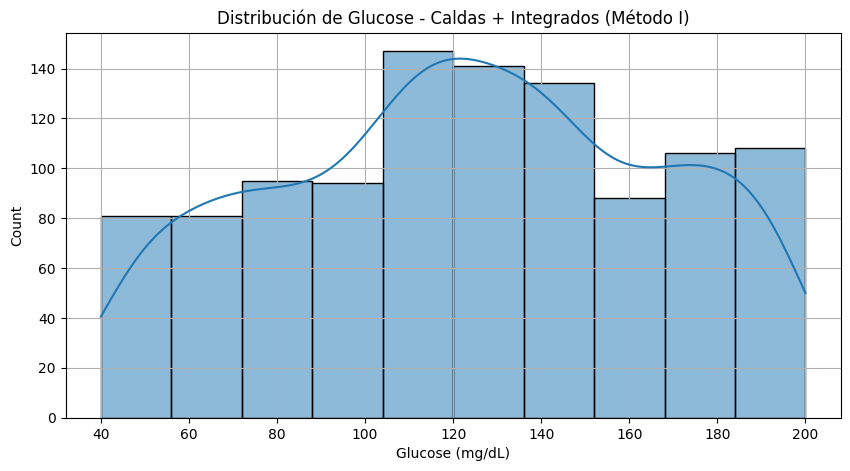

El número de datos por intervalo es:
[ 81  81  95  94 147 141 134  88 106 108]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   81.0
1   56.0   72.0   64.0   81.0
2   72.0   88.0   80.0   95.0
3   88.0  104.0   96.0   94.0
4  104.0  120.0  112.0  147.0
5  120.0  136.0  128.0  141.0
6  136.0  152.0  144.0  134.0
7  152.0  168.0  160.0   88.0
8  168.0  184.0  176.0  106.0
9  184.0  200.0  192.0  108.0

Media: 123.6986
Desviación Estándar: 43.0690
Coeficiente de Asimetría: -0.0886
Kurtosis: -0.9961

''''''''''''''''''''''''''''''''''''''''''''''''''
Media datos destino (Caldas) ANTES: 123.3883
Media datos integrados DESPUÉS: 123.6986
Discrepancia entre las medias: 0.2515%

Sigma datos destino (Caldas) ANTES: 46.4903
Sigma datos integrados DESPUÉS: 43.0690
Discrepancia entre las sigmas: 7.3592%


In [ ]:
#Se validan las propiedades estadísticas después de la integración
ui1,sigmai1,Casi1,Kuri1,dfi1=caracterizacion(LDAint1,f"{mejor_sucursal} + Integrados (Método I)")

print("\n" + "'"*50)
print(f"Media datos destino ({mejor_sucursal}) ANTES: {u_dest:.4f}")
print(f"Media datos integrados DESPUÉS: {ui1:.4f}")
disc_u1=np.abs((u_dest-ui1)/u_dest)*100
print(f"Discrepancia entre las medias: {disc_u1:.4f}%")

print(f"\nSigma datos destino ({mejor_sucursal}) ANTES: {sigma_dest:.4f}")
print(f"Sigma datos integrados DESPUÉS: {sigmai1:.4f}")
disc_s1=np.abs((sigma_dest-sigmai1)/sigma_dest)*100
print(f"Discrepancia entre las sigmas: {disc_s1:.4f}%")

**4. Se procede con la integración mediante el Método de Aceptación/Rechazo II**

In [ ]:
#Método II: Aceptación/Rechazo - Se comparan los valores de pertenencia internos vs externos
#VPo: Qué tanto se parece el dato de Sabaneta a los datos de la sucursal destino
#VPe: Qué tan representativo es el dato en la distribución de Sabaneta

LDAint2=np.copy(LDA_destino)

m2=0
for k in range(len(LDA_ext)):   #Se recorren los datos de Sabaneta
  VPo=np.exp(-0.5*((u_dest-LDA_ext[k])/sigma_dest)**2)   #Pertenencia a la sucursal destino
  VPe=np.exp(-0.5*((u_sab-LDA_ext[k])/sigma_sab)**2)     #Pertenencia a Sabaneta

  if VPo>VPe:
    m2=m2+1
    LDAint2=np.append(LDAint2,LDA_ext[k])

print(f"Datos de Sabaneta integrados (Método II - VPo>VPe): {m2} de {len(LDA_ext)}")
print(f"Total de datos después de integración: {len(LDAint2)}")

Datos de Sabaneta integrados (Método II - VPo>VPe): 292 de 621
Total de datos después de integración: 1201


4.1 Validación de propiedades estadísticas después de la integración (Método II)

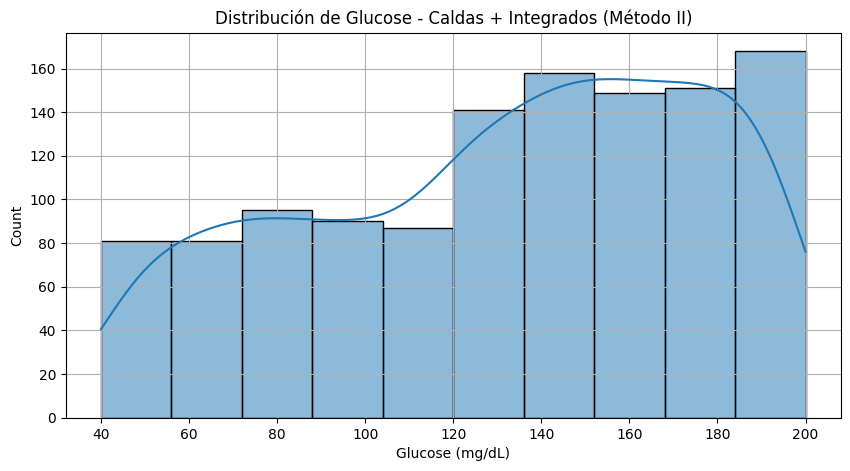

El número de datos por intervalo es:
[ 81  81  95  90  87 141 158 149 151 168]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   81.0
1   56.0   72.0   64.0   81.0
2   72.0   88.0   80.0   95.0
3   88.0  104.0   96.0   90.0
4  104.0  120.0  112.0   87.0
5  120.0  136.0  128.0  141.0
6  136.0  152.0  144.0  158.0
7  152.0  168.0  160.0  149.0
8  168.0  184.0  176.0  151.0
9  184.0  200.0  192.0  168.0

Media: 131.9967
Desviación Estándar: 44.6409
Coeficiente de Asimetría: -0.3652
Kurtosis: -1.0162

''''''''''''''''''''''''''''''''''''''''''''''''''
Media datos destino (Caldas) ANTES: 123.3883
Media datos integrados DESPUÉS: 131.9967
Discrepancia entre las medias: 6.9766%

Sigma datos destino (Caldas) ANTES: 46.4903
Sigma datos integrados DESPUÉS: 44.6409
Discrepancia entre las sigmas: 3.9782%


In [ ]:
#Se validan las propiedades estadísticas después de la integración
ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(LDAint2,f"{mejor_sucursal} + Integrados (Método II)")

print("\n" + "'"*50)
print(f"Media datos destino ({mejor_sucursal}) ANTES: {u_dest:.4f}")
print(f"Media datos integrados DESPUÉS: {ui2:.4f}")
disc_u2=np.abs((u_dest-ui2)/u_dest)*100
print(f"Discrepancia entre las medias: {disc_u2:.4f}%")

print(f"\nSigma datos destino ({mejor_sucursal}) ANTES: {sigma_dest:.4f}")
print(f"Sigma datos integrados DESPUÉS: {sigmai2:.4f}")
disc_s2=np.abs((sigma_dest-sigmai2)/sigma_dest)*100
print(f"Discrepancia entre las sigmas: {disc_s2:.4f}%")

**5. Se procede con la integración mediante el Método de Aceptación/Rechazo III**

In [ ]:
#Método III: Aceptación/Rechazo con componente aleatorio
#Se integra el dato si VPo/VPe > aleatorio

LDAint3=np.copy(LDA_destino)

m3=0
for k in range(len(LDA_ext)):   #Se recorren los datos de Sabaneta
  VPo=np.exp(-0.5*((u_dest-LDA_ext[k])/sigma_dest)**2)   #Pertenencia a la sucursal destino
  VPe=np.exp(-0.5*((u_sab-LDA_ext[k])/sigma_sab)**2)     #Pertenencia a Sabaneta
  aleatorio=np.random.rand()

  if VPo/VPe>aleatorio:
    m3=m3+1
    LDAint3=np.append(LDAint3,LDA_ext[k])

print(f"Datos de Sabaneta integrados (Método III - VPo/VPe>aleatorio): {m3} de {len(LDA_ext)}")
print(f"Total de datos después de integración: {len(LDAint3)}")

Datos de Sabaneta integrados (Método III - VPo/VPe>aleatorio): 595 de 621
Total de datos después de integración: 1504


5.1 Validación de propiedades estadísticas después de la integración (Método III)

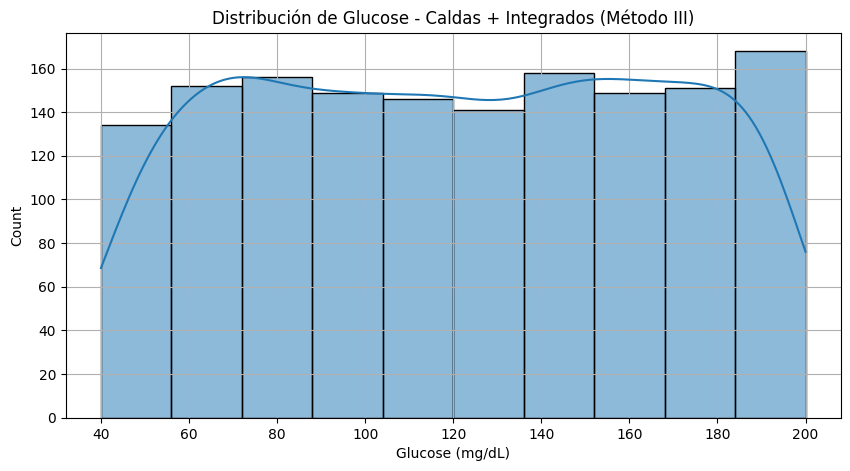

El número de datos por intervalo es:
[134 152 156 149 146 141 158 149 151 168]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0  134.0
1   56.0   72.0   64.0  152.0
2   72.0   88.0   80.0  156.0
3   88.0  104.0   96.0  149.0
4  104.0  120.0  112.0  146.0
5  120.0  136.0  128.0  141.0
6  136.0  152.0  144.0  158.0
7  152.0  168.0  160.0  149.0
8  168.0  184.0  176.0  151.0
9  184.0  200.0  192.0  168.0

Media: 121.5213
Desviación Estándar: 46.0941
Coeficiente de Asimetría: -0.0163
Kurtosis: -1.2399

''''''''''''''''''''''''''''''''''''''''''''''''''
Media datos destino (Caldas) ANTES: 123.3883
Media datos integrados DESPUÉS: 121.5213
Discrepancia entre las medias: 1.5132%

Sigma datos destino (Caldas) ANTES: 46.4903
Sigma datos integrados DESPUÉS: 46.0941
Discrepancia entre las sigmas: 0.8523%


In [ ]:
#Se validan las propiedades estadísticas después de la integración
ui3,sigmai3,Casi3,Kuri3,dfi3=caracterizacion(LDAint3,f"{mejor_sucursal} + Integrados (Método III)")

print("\n" + "'"*50)
print(f"Media datos destino ({mejor_sucursal}) ANTES: {u_dest:.4f}")
print(f"Media datos integrados DESPUÉS: {ui3:.4f}")
disc_u3=np.abs((u_dest-ui3)/u_dest)*100
print(f"Discrepancia entre las medias: {disc_u3:.4f}%")

print(f"\nSigma datos destino ({mejor_sucursal}) ANTES: {sigma_dest:.4f}")
print(f"Sigma datos integrados DESPUÉS: {sigmai3:.4f}")
disc_s3=np.abs((sigma_dest-sigmai3)/sigma_dest)*100
print(f"Discrepancia entre las sigmas: {disc_s3:.4f}%")

**6. Resumen Comparativo de los Tres Métodos de Integración**

In [ ]:
#Se construye la tabla comparativa de los tres métodos
print("="*80)
print("RESUMEN COMPARATIVO DE LOS MÉTODOS DE INTEGRACIÓN")
print("="*80)
print(f"{'Métrica':<30} {'Antes':<15} {'Método I':<15} {'Método II':<15} {'Método III':<15}")
print("-"*80)
print(f"{'Número de Datos':<30} {len(LDA_destino):<15} {len(LDAint1):<15} {len(LDAint2):<15} {len(LDAint3):<15}")
print(f"{'Datos Integrados':<30} {'-':<15} {m1:<15} {m2:<15} {m3:<15}")
print(f"{'Media':<30} {u_dest:<15.4f} {ui1:<15.4f} {ui2:<15.4f} {ui3:<15.4f}")
print(f"{'Sigma':<30} {sigma_dest:<15.4f} {sigmai1:<15.4f} {sigmai2:<15.4f} {sigmai3:<15.4f}")
print(f"{'Asimetría':<30} {Cas_sab:<15.4f} {Casi1:<15.4f} {Casi2:<15.4f} {Casi3:<15.4f}")
print(f"{'Kurtosis':<30} {Kur_sab:<15.4f} {Kuri1:<15.4f} {Kuri2:<15.4f} {Kuri3:<15.4f}")
print(f"{'Discrepancia Media (%)':<30} {'-':<15} {disc_u1:<15.4f} {disc_u2:<15.4f} {disc_u3:<15.4f}")
print(f"{'Discrepancia Sigma (%)':<30} {'-':<15} {disc_s1:<15.4f} {disc_s2:<15.4f} {disc_s3:<15.4f}")

RESUMEN COMPARATIVO DE LOS MÉTODOS DE INTEGRACIÓN
Métrica                        Antes           Método I        Método II       Método III     
--------------------------------------------------------------------------------
Número de Datos                909             1075            1201            1504           
Datos Integrados               -               166             292             595            
Media                          123.3883        123.6986        131.9967        121.5213       
Sigma                          46.4903         43.0690         44.6409         46.0941        
Asimetría                      0.1115          -0.0886         -0.3652         -0.0163        
Kurtosis                       -1.2023         -0.9961         -1.0162         -1.2399        
Discrepancia Media (%)         -               0.2515          6.9766          1.5132         
Discrepancia Sigma (%)         -               7.3592          3.9782          0.8523         


**De lo anterior se puede observar:**

1. **Credibilidad:** Se estimó la credibilidad entre Sabaneta y cada una de las sucursales disponibles (Bello, Medellín, Envigado, Caldas) utilizando la variable Glucose como referencia. La sucursal con mayor credibilidad (mayor afinidad), Caldas, fue seleccionada como destino para la integración de pacientes.
2. **Método I (Valor de Pertenencia):** Se integraron los pacientes de Sabaneta cuyo valor de pertenencia a la distribución de la sucursal destino fue mayor a 0.9. Este es el método más conservador.
3. **Método II (Aceptación/Rechazo):** Se integraron los pacientes de Sabaneta cuando su valor de pertenencia a la sucursal destino (VPo) fue mayor que su pertenencia a Sabaneta (VPe). Este método permite integrar datos que se ajustan mejor al perfil de la sucursal receptora.
4. **Método III (Aceptación/Rechazo Aleatorio):** Se integraron los pacientes cuando la razón VPo/VPe fue mayor que un número aleatorio. Este método introduce variabilidad en la selección y tiende a integrar más datos.
5. **Estabilidad:** Se verificó que las medidas de tendencia central y dispersión (media y desviación estándar) se mantuvieron estables antes y después de cada integración, lo cual se evidencia en las bajas discrepancias porcentuales observadas.

# **Análisis de los Datos:**

Las distribuciones de Glucose (mg/dL) de las cinco sucursales presentan medias entre 116.61 (Sabaneta) y 123.39 (Caldas), desviaciones estándar entre 44.63 y 46.85, asimetrías cercanas a cero y kurtosis negativas en torno a -1.2. Esto confirma que todas las sucursales atienden poblaciones con perfiles clínicos similares en esta variable, con distribuciones platicúrticas y aproximadamente simétricas, lo cual constituye un escenario favorable para la integración de datos.

La aplicación de la Teoría de la Credibilidad arrojó que Caldas es la sucursal con mayor afinidad respecto a Sabaneta, con una credibilidad del 99.33%. Le siguen Medellín (99.16%), Envigado (98.43%) y Bello (96.25%). Aunque todas superan el 96%, Caldas se distingue por tener el menor factor de credibilidad (fc = 4.17) y el mayor VWM (11.07), lo que indica que la estructura estadística de sus datos es la más compatible con la de Sabaneta. Por esta razón, fue seleccionada como sucursal destino para la integración de los 621 pacientes.

En cuanto a los métodos de integración, el Método I (Valor de Pertenencia, VP > 0.9) resultó ser el más conservador: integró solo 166 pacientes (26.7%) con una discrepancia en media de apenas 0.25%, pero a costa de comprimir la desviación estándar en un 7.36% y dejar sin reubicar al 73% de los pacientes. El Método II (Aceptación/Rechazo, VPo > VPe) integró 292 pacientes (47.0%), pero introdujo el mayor sesgo en la media (6.98%), desplazándola de 123.39 a 132.00 e incrementando la asimetría negativa a -0.37, lo que distorsiona el perfil original de Caldas. El Método III (Aceptación/Rechazo Aleatorio, VPo/VPe > aleatorio) integró 595 pacientes (95.8%) logrando las menores discrepancias combinadas: 1.51% en media y 0.85% en sigma, con asimetría y kurtosis prácticamente inalteradas respecto a la distribución original.

Por lo analizado anteriormente, considero que el Método III es el más adecuado para los objetivos de la entidad prestadora de salud, ya que maximiza la cobertura de pacientes reubicados mientras preserva de forma óptima las propiedades estadísticas de la sucursal receptora. Se recomienda ejecutarlo en múltiples iteraciones para verificar la robustez de los resultados dada su naturaleza estocástica.